Praktikum 5.1 – Persiapan Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

Praktikum 5.2 – Import Dataset

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print("Ukuran data:", X.shape)
print("Distribusi kelas:", np.bincount(y))

Ukuran data: (569, 30)
Distribusi kelas: [212 357]


Praktikum 5.3 – Preprocessing (Split Data)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Praktikum 5.4 – Training Model (dengan dan tanpa Pruning)

In [4]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Model dengan pre-pruning
tree_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                     random_state=42)
tree_pruned.fit(X_train, y_train)

# Model dengan post-pruning (Cost Complexity Pruning)
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alpha_terpilih = path.ccp_alphas[len(path.ccp_alphas) // 2]  # contoh pemilihan alpha
tree_ccp = DecisionTreeClassifier(ccp_alpha=ccp_alpha_terpilih,
                                  random_state=42)
tree_ccp.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.005274725274725275),
                       random_state=42)

Praktikum 5.5 – Evaluasi

In [5]:
for nama, model in [("Tanpa Pruning", tree_full),
                    ("Pre-Pruning", tree_pruned),
                    ("Post-Pruning (CCP)", tree_ccp)]:
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test = accuracy_score(y_test, model.predict(X_test))
    print(f"{nama}: Akurasi Train={acc_train:.3f}, "
          f"Akurasi Test={acc_test:.3f}, "
          f"Gap={acc_train-acc_test:.3f}")

Tanpa Pruning: Akurasi Train=1.000, Akurasi Test=0.912, Gap=0.088
Pre-Pruning: Akurasi Train=0.976, Akurasi Test=0.921, Gap=0.055
Post-Pruning (CCP): Akurasi Train=0.978, Akurasi Test=0.930, Gap=0.048


Praktikum 5.6 - Visualisasi

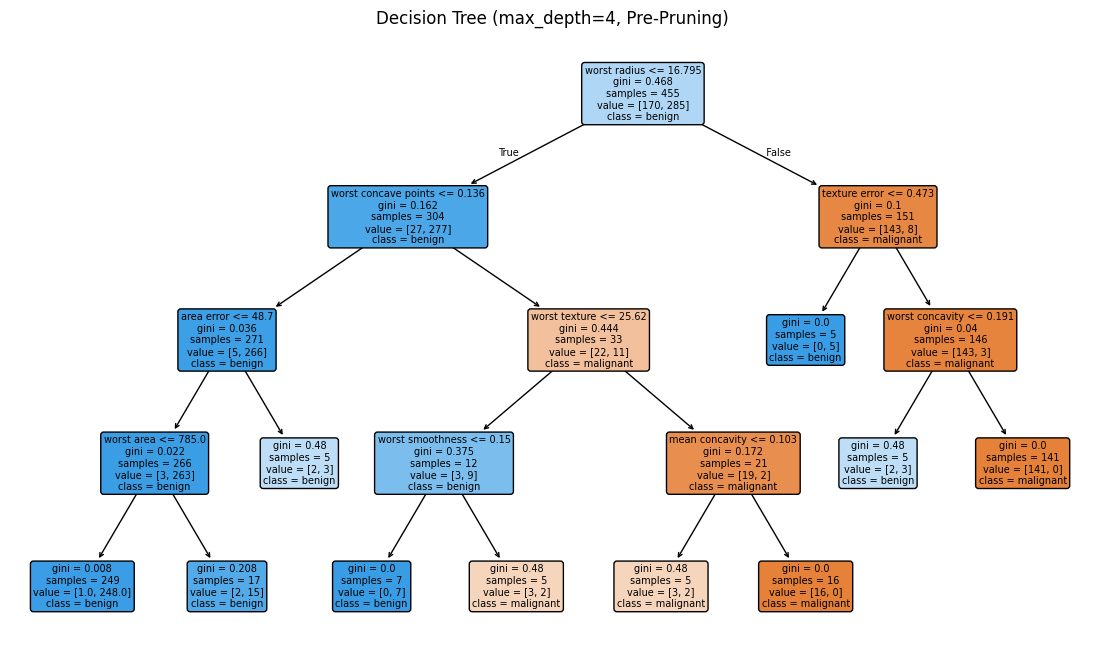

In [6]:
plt.figure(figsize=(14, 8))
plot_tree(tree_pruned, feature_names=data.feature_names,
          class_names=data.target_names, filled=True, rounded=True,
          fontsize=7)
plt.title("Decision Tree (max_depth=4, Pre-Pruning)")
plt.show()